# Đề thi Giữa kỳ Graph mining 2024.

### Khoa học dữ liệu IUH. Ca 1. Thời gian làm bài: 90 phút (được dùng tài liệu Internet).

### Bài 1. (3.0 = 1+1+1đ)

Bài này dựa trên bộ data có sẵn Zachary's Karate Club của thư viện networkx. Hãy thực hiện các yêu cầu sau:

1) Import graph này và gọi $A$ là ma trận kề của graph này. In ra ma trận $B = A^3$ và cho biết mỗi phần tử ở vị trí $(i,j)$ trên ma trận $B$ có ý nghĩa gì.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
import pandas as pd
#CODE HERE
G = nx.karate_club_graph()

In [8]:
A = nx.adjacency_matrix(G).todense()
A

array([[0, 4, 5, ..., 2, 0, 0],
       [4, 0, 6, ..., 0, 0, 0],
       [5, 6, 0, ..., 0, 2, 0],
       ...,
       [2, 0, 0, ..., 0, 4, 4],
       [0, 0, 2, ..., 4, 0, 5],
       [0, 0, 0, ..., 4, 5, 0]], dtype=int32)

In [9]:
B = np.linalg.matrix_power(A, 3)

print("Ma trận B = A^3:")
print(B)
print("\nÝ nghĩa của mỗi phần tử ở vị trí (i, j) trên ma trận B:")
print("Mỗi phần tử ở vị trí (i, j) trên ma trận B cho biết số đường đi có chiều dài 3 từ đỉnh i đến đỉnh j trong đồ thị.")

Ma trận B = A^3:
[[1242 1455 1725 ...  586  372  480]
 [1455 1218 1812 ...  332  399  507]
 [1725 1812 1266 ...  404  952  656]
 ...
 [ 586  332  404 ...  248 1399 1454]
 [ 372  399  952 ... 1399 1174 1700]
 [ 480  507  656 ... 1454 1700 1252]]

Ý nghĩa của mỗi phần tử ở vị trí (i, j) trên ma trận B:
Mỗi phần tử ở vị trí (i, j) trên ma trận B cho biết số đường đi có chiều dài 3 từ đỉnh i đến đỉnh j trong đồ thị.


2) Cho biết index của đỉnh có bậc cao nhất, đặt là $u$ và index của đỉnh có bậc thấp nhất, đặt là $v$ (nếu có nhiều đỉnh như thế thì chọn ra một đỉnh tùy ý trong đó). Tô màu đỏ cho 2 đỉnh đó, các đỉnh còn lại tô xanh rồi trực quan dựa theo code bên dưới.

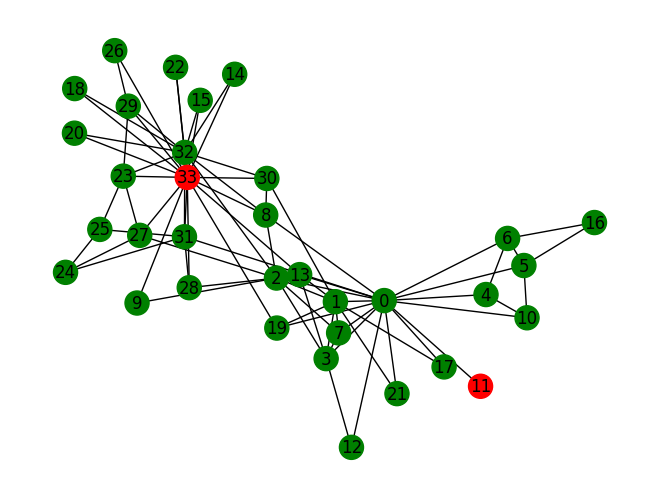

In [10]:
#CODE HERE

# Tính bậc của từng đỉnh
degrees = dict(G.degree())

# Tìm index của đỉnh có bậc cao nhất và bậc thấp nhất
highest_degree_node = max(degrees, key=degrees.get)
lowest_degree_node = min(degrees, key=degrees.get)

colors = []

for v in G.nodes:
    if v == highest_degree_node or v == lowest_degree_node:
        colors.append('red')
    else:
        colors.append('green')

nx.draw(G, with_labels=True, node_color=colors)
plt.show()

3) Vẽ cây DFS tạo thành bằng cách duyệt graph từ đỉnh $x$, trong đó $x$ là tổng ba chữ số cuối trong MSSV của anh/chị. Một sinh viên cho rằng: "nếu đỉnh $y$ có cạnh nối với $x$ thì nhờ DFS chắc chắn sẽ được thăm sớm hơn các đỉnh không có cạnh nối với $x$", hỏi bạn này nhận xét đúng hay sai? Vì sao?

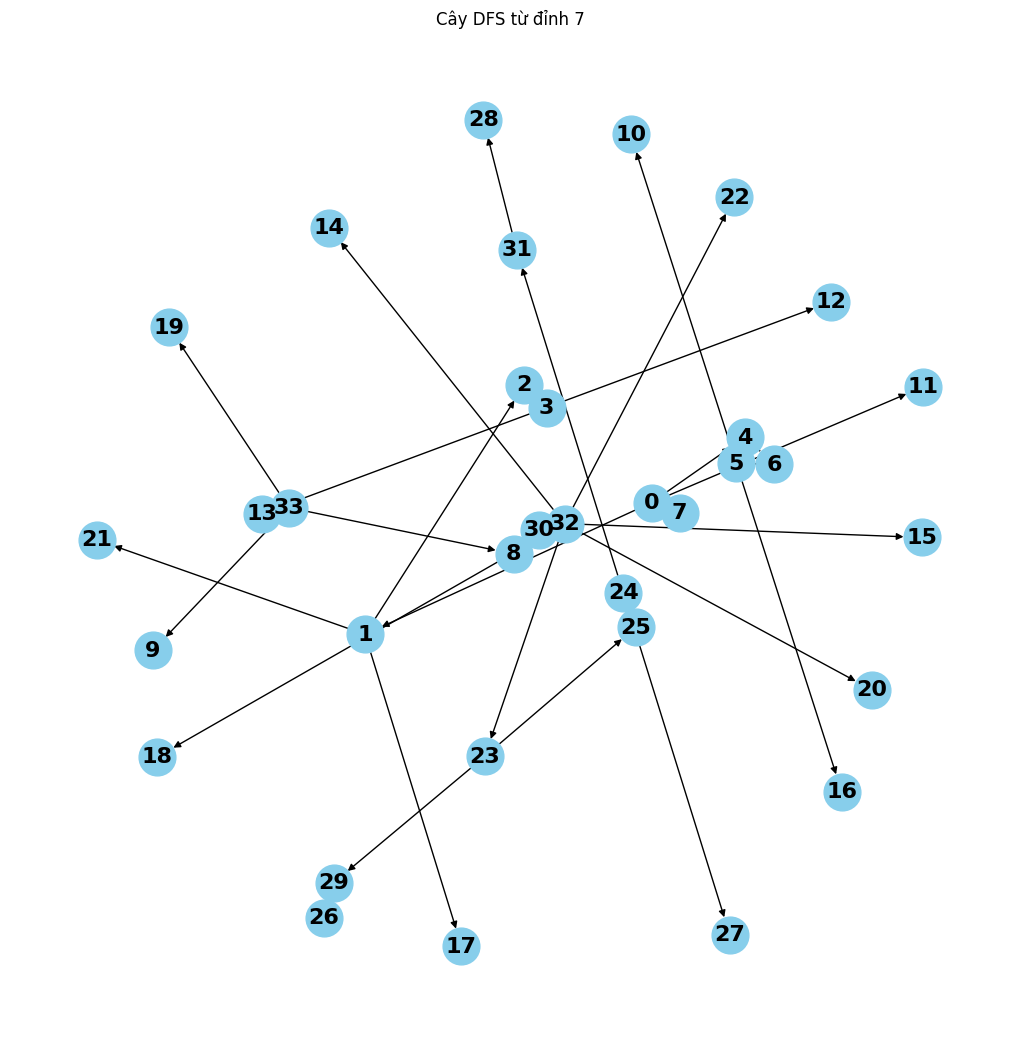

In [11]:
#CODE HERE
MSSV = 21094601
s_mssv = 7

dfs_tree = nx.dfs_tree(G, source=s_mssv)

# Vẽ cây DFS
plt.figure(figsize=(10, 10))
nx.draw(dfs_tree, with_labels=True, node_color='skyblue', font_weight='bold', node_size=700, font_size=16)
plt.title("Cây DFS từ đỉnh 7")
plt.show()

Nhận xét của sinh viên là **sai** vì trong thuật toán Duyệt Sâu (DFS - Depth First Search), việc thăm các đỉnh không chỉ phụ thuộc vào sự tồn tại của cạnh nối trực tiếp từ đỉnh đang xét đến các đỉnh khác, mà còn phụ thuộc vào trật tự thăm các đỉnh và cấu trúc của đồ thị.

Thuật toán DFS bắt đầu từ một đỉnh ban đầu, sau đó từ đỉnh này, nó tiếp tục duyệt sâu vào các đỉnh kề chưa được thăm qua cạnh nối của chúng. Quá trình này tiếp diễn cho đến khi không còn đỉnh kề nào chưa được thăm hoặc đã thăm hết tất cả các đỉnh có thể từ đỉnh ban đầu. Khi đó, DFS sẽ quay lui (backtrack) để thăm các đỉnh chưa được thăm thông qua các đỉnh đã thăm trước đó.

Trong một số trường hợp, một đỉnh \(y\) có thể có cạnh nối trực tiếp với đỉnh \(x\) nhưng không được thăm sớm hơn một số đỉnh không có cạnh nối trực tiếp với \(x\), nếu:

1. **Trật tự thăm:** Trong quá trình duyệt, nếu các đỉnh kề với \(x\) được duyệt theo một trật tự nhất định và đỉnh \(y\) không phải là đỉnh kề đầu tiên được duyệt từ \(x\), các đỉnh kề khác (không phải là \(y\)) có thể được thăm trước \(y\).

2. **Cấu trúc đồ thị:** Trong một số cấu trúc đồ thị, việc duyệt có thể đi sâu vào một nhánh không chứa \(y\) trước khi quay lại và thăm \(y\), đặc biệt nếu nhánh đó dẫn đến một số đỉnh kề khác trước khi đến được \(y\).

Do đó, việc một đỉnh \(y\) có cạnh nối trực tiếp với đỉnh \(x\) không đảm bảo rằng \(y\) sẽ được thăm sớm hơn tất cả các đỉnh không có cạnh nối trực tiếp với \(x\) trong quá trình thực hiện DFS.

### Bài 2. (2.0 = 1 + 1 đ) Trong BA chọn HAI:

1) Cho graph $G$ được mô tả bởi thông tin bên dưới. Tính giá trị của hệ số trung tâm closeness của đỉnh $4$ bằng 2 cách: dùng thư viện và tính toán trực tiếp.

In [12]:
G_sample1 = {
  '1' : ['2', '3'],
  '2' : ['1', '3'],
  '3' : ['1', '2', '4'],
  '4' : ['3', '5'],
  '5' : ['4', '6'],
  '6' : ['5']
}

$$C(u) = \frac{n-1}{\sum_{y = 1}^{n-1}d(v, u)}$$

In [13]:
#CODE HERE
G = nx.Graph(G_sample1)

# Tính hệ số trung tâm closeness bằng thư viện NetworkX
closeness_centrality = nx.closeness_centrality(G)
closeness_centrality_lib = closeness_centrality['4']

print('hệ số trung tâm closeness bằng thư viện NetworkX:', closeness_centrality_lib)


# Tính toán trực tiếp
# Tính khoảng cách ngắn nhất từ đỉnh 4 đến tất cả các đỉnh khác
distances = nx.single_source_shortest_path_length(G, '4')
# Tính trung bình cộng khoảng cách
average_distance = sum(distances.values()) / (len(distances)-1)
# Tính hệ số trung tâm closeness trực tiếp
closeness_centrality_direct = 1 / average_distance
print('hệ số trung tâm closeness bằng tính toán trực tiếp:',  closeness_centrality_direct)


hệ số trung tâm closeness bằng thư viện NetworkX: 0.625
hệ số trung tâm closeness bằng tính toán trực tiếp: 0.625


2) Một graph đơn vô hướng có $12$ đỉnh với thông tin như sau: đỉnh $1$ nối với các đỉnh $2,3,4,5$, còn đỉnh $2$ nối với các đỉnh $1,7,8,9,10,11,12$. Hỏi tập độc lập lớn nhất của graph này có kích thước là bao nhiêu? Giải thích và in ra một ví dụ ứng với kích thước tìm được.

In [14]:
#CODE HERE

# Tạo đồ thị
G = nx.Graph()

# Thêm các đỉnh và cạnh
G.add_edges_from([(1, 2), (1, 3), (1, 4), (1, 5), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12)])

# Tìm tập độc lập lớn nhất
max_ind_set = nx.maximal_independent_set(G)

print("Tập độc lập lớn nhất có kích thước:", len(max_ind_set))
print("Tập độc lập lớn nhất:", max_ind_set)


Tập độc lập lớn nhất có kích thước: 9
Tập độc lập lớn nhất: [8, 10, 5, 3, 4, 12, 7, 11, 9]


**Để tìm tập độc lập lớn nhất của một đồ thị, ta cần tìm tập con của tất cả các đỉnh mà không có cạnh nào kết nối hai đỉnh trong tập con đó , ta có thể sử dụng giải thuật tham lam (greedy algorithm) bằng cách chọn đỉnh có số lượng cạnh kề ít nhất cho tập độc lập, sau đó loại bỏ các đỉnh kề với đỉnh đã chọn và lặp lại quá trình cho đến khi không còn đỉnh nào kề.**

3) Một graph đều (regular) có $20$ đỉnh thì số cạnh có thể có là bao nhiêu? Vì sao?

Trong lý thuyết đồ thị, một đồ thị chính quy, còn gọi là đồ thị đều (tiếng Anh: regular graph) là một đồ thị trong đó mỗi đỉnh có số láng giềng bằng nhau, nghĩa là các đỉnh có bậc bằng nhau.  Hay giữa hai đỉnh bất kỳ luôn tồn tại cạnh nối trực tiếp nên 

+ số cạnh có thể có bằng: n*(n-1)/2 (số cách chọn 2 đỉnh  bất kỳ trong n đỉnh)
+ trong đó n là số đỉnh


In [15]:
#CODE HERE
n = 20
max_edg = n*(n-1)//2
print('số cạnh tối đa có thể có:', max_edg, 'cạnh')

số cạnh tối đa có thể có: 190 cạnh


### Bài 3. (2.5 = 1 + 1.5đ)

Sinh ngẫu nhiên một graph đơn, vô hướng, có tất cả $27$ đỉnh $100$ cạnh có trọng số nguyên thuộc miền $[-24,24]$ và liên thông (nếu graph không liên thông, anh/chị thực hiện sinh ngẫu nhiên tiếp cho đến khi nào liên thông thì thôi). Từ đó, thực hiện các yêu cầu sau:

1) Vẽ cây khung nhỏ nhất của graph dựa trên một trong hai thuật toán Prim / Kruskal, từ đó tính tổng trọng số nhỏ nhất đó. Hãy nêu ứng dụng của thuật toán tìm cây khung trong thực tế.

In [11]:
import networkx as nx
import random
def generate_random_graph(vertices, edges, weight_range):
    G = nx.Graph()
    G.add_nodes_from(range(vertices))
    for _ in range(edges):
        u = random.randint(0, vertices - 1)
        v = random.randint(0, vertices - 1)
        while u == v or G.has_edge(u, v):
            u = random.randint(0, vertices - 1)
            v = random.randint(0, vertices - 1)
        w = random.randint(weight_range[0], weight_range[1])
        G.add_edge(u, v, weight=w)
    return G

data = []
for i in range(11):
    G3 = generate_random_graph(15, 92, [-23, 23])
    data.append(G3)
    print(nx.number_connected_components(G3))
print(len(G3))

1
1
1
1
1
1
1
1
1
1
1
15


Cây khung nhỏ nhất dựa trên thuật toán Kruskal:
0 - 20: -19
0 - 23: -14
0 - 15: -13
1 - 19: -16
2 - 24: -11
3 - 5: -6
4 - 15: -13
5 - 18: -18
5 - 19: -17
5 - 14: -2
6 - 7: -17
6 - 22: -13
7 - 18: -15
7 - 17: -13
8 - 24: -23
8 - 13: -16
8 - 20: -14
9 - 26: -11
10 - 19: -23
11 - 20: -8
12 - 18: -6
16 - 21: -21
16 - 22: -17
20 - 25: -18
20 - 21: -15
21 - 26: -21
Tổng trọng số nhỏ nhất: -380


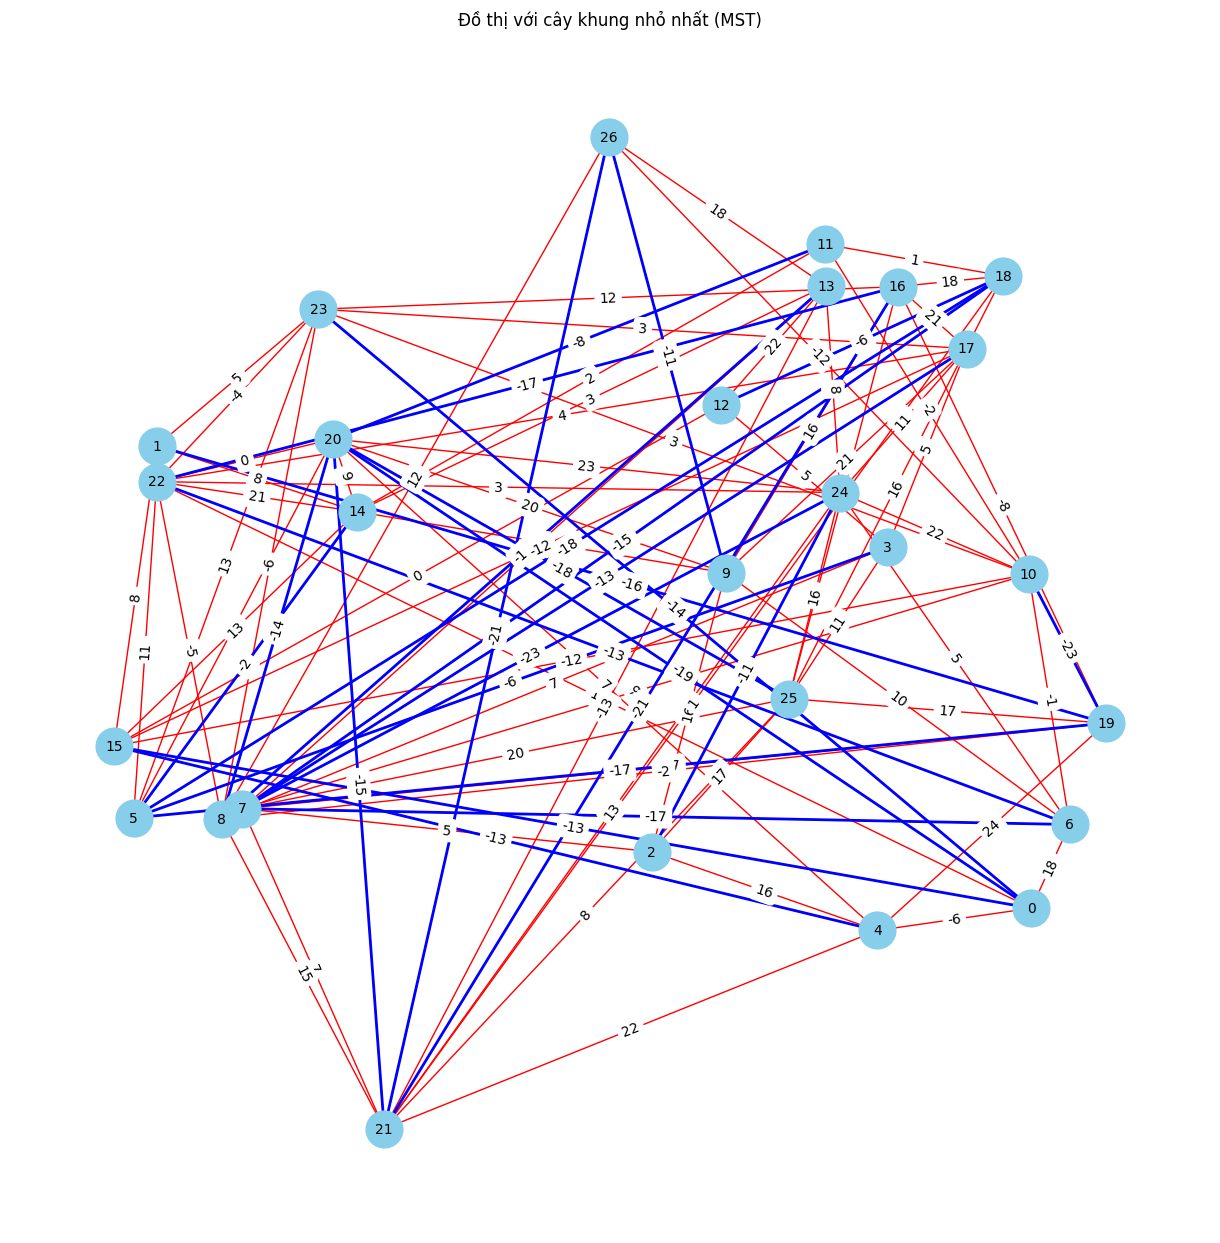

In [17]:
def kruskal_mst(G):
    mst = nx.minimum_spanning_tree(G)
    min_cost = sum([edge[2] for edge in mst.edges(data='weight')])
    return mst, min_cost

def plot_graph_with_mst(G, mst):
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G)  
    
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=700, font_size=10, edge_color='red') # vẽ đồ thị cạnh màu đỏ không có trọng số 
    nx.draw_networkx_edges(mst, pos, edge_color='blue', width=2)   # vẽ cây MST bằng màu xanh dương 
    edge_labels = {(u, v): w for u, v, w in G.edges(data='weight')}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)  # vẽ thêm trọng số 
    plt.title("Đồ thị với cây khung nhỏ nhất (MST)")
    plt.show()
    
mst, min_cost = kruskal_mst(G3)

print("Cây khung nhỏ nhất dựa trên thuật toán Kruskal:")
for u, v, w in mst.edges(data='weight'):
    print(f"{u} - {v}: {w}")
print("Tổng trọng số nhỏ nhất:", min_cost)
plot_graph_with_mst(G3, mst)

# => Tối Ưu Hóa Đường Dây Điện và Mạng Cấp Nước
Tối ưu hóa đường dây điện: Trong việc phân phối điện năng, việc lựa chọn đường dây sao cho chi phí thấp nhất mà vẫn đảm bảo cung cấp điện cho tất cả các điểm cần thiết có thể được mô hình hóa và giải quyết thông qua việc tìm cây khung tối thiểu.

2) Sử dụng hàm negative_edge_cycle trong thư viện networkx để xác định chu trình âm trong graph này:
- Nếu có chu trình âm thì in các đỉnh đó ra.
- Nếu không có chu trình âm thì sử dụng thuật toán Dijkstra để tính đường đi ngắn nhất giữa hai đỉnh có chỉ số là $a*b$ và $a+b$, trong đó $a$, $b$ là chữ số lớn nhất và nhỏ nhất (khác $0$) trong MSSV của anh/chị.

Hỏi cơ sở lý thuyết của thư viện đó là dựa trên thuật toán nào? 

In [18]:
#CODE HERE


# def find_negative_cycl(digraph, start="USD"):
#     try:
#         path = nx.bellman_ford(digraph, start) 
#         return path
#     except NetworkXUnbounded:
#         cycles = nx.simple_cycles(digraph)
#         for cycle in cycles:
#             print(cycle)  # do whatever you prefer here of course
def getW(edge):
    return edge[2]['weight']


def  find_negative_cycle(g):
    n = len(g.nodes())
    edges = list(g.edges().data())
    d = np.ones(n) * 10000
    p = np.ones(n)*-1
    x = -1
    for i in range(n):        
        for e in edges:
            if d[int(e[0])] + getW(e) < d[int(e[1])]:
                d[int(e[1])] = d[int(e[0])] + getW(e)
                p[int(e[1])] = int(e[0])
                x = int(e[1])
    if x == -1:
        print("No negative cycle")
        return None
    for i in range(n):
        x = p[int(x)]
    cycle = []
    v = x
    while True:
        cycle.append(str(int(v)))
        if v == x and len(cycle) > 1:
            break
        v = p[int(v)]
    return list(reversed(cycle))

 
# Định nghĩa đồ thị
G = nx.DiGraph()
G.add_weighted_edges_from([(0, 1, 5), (1, 2, 20), (2, 3, 10), (3, 1, -60), (1, 4, -50)])

# Tìm chu trình âm
negative_cycle = find_negative_cycle(G)
print("Chu trình âm:", negative_cycle)

# Kiểm tra sự tồn tại của chu trình âm
has_negative_edge_cycle = nx.negative_edge_cycle(G3)

# Nếu có chu trình âm, xuất các đỉnh của chu trình
# Nếu không, tính đường đi ngắn nhất giữa hai đỉnh a*b và a+b, với a = 9 và b = 1
if has_negative_edge_cycle:
    print("Đồ thị có chu trình âm.", find_negative_cycle(G3))
else:
    a, b = 9, 1
    # Tính đường đi ngắn nhất bằng thuật toán Dijkstra
    shortest_path = nx.dijkstra_path(G_example, source=a*b, target=a+b)
    print("Đường đi ngắn nhất:", shortest_path)

has_negative_edge_cycle


Chu trình âm: ['2', '3', '1', '2']
Đồ thị có chu trình âm. ['6', '7', '10', '11', '20', '21', '-1', '6']


True

**Cơ sở lý thuyết của hàm negative_edge_cycle trong thư viện NetworkX dựa trên thuật toán Bellman-Ford, cho phép phát hiện sự tồn tại của chu trình âm trong đồ thị có trọng số, kể cả khi trọng số đó âm.**

### Bài 4. (2.0 = 1+1đ)

Mạng lưới thông tin của các tên khủng bố được cho trong dữ liệu terrorist, gồm các file terrorist.pairs, terrorist.names, trong đó liên hệ của họ được mô tả bởi các cạnh có hướng. Hãy thực hiện các yêu cầu sau:

0) Đọc dữ liệu về tên và các cặp khủng bố có liên hệ nhau, in danh sách $10$ cặp tên đầu tiên của các tên khủng bố (đã có code tham khảo nên SV chỉ cần chạy code). 

1) Chuyển đổi dữ liệu sang DiGraph và vẽ graph này ra.

2) Thực hiện thuật toán pagerank, lấy hằng số $\alpha = 0.85$, in ra ma trận khởi tạo và bảng sắp thứ tự tên của các tên khủng bố cùng rank của họ (đã có code tham khảo). Hỏi hằng số $alpha$ này dùng để làm gì?

In [3]:
# anh/chị chỉ cần chạy code này để đọc dữ liệu
edge_list = np.loadtxt('terrorist.pairs', dtype=str)
node_name_dict = dict(np.loadtxt('terrorist.names', dtype=str))
edge_list = [(node_name_dict[source], node_name_dict[target]) for source, target in edge_list]
edge_list[:10]

[('Samir_Kashk', 'Essid_Sami_Ben_Khemais'),
 ('Madjid_Sahoune', 'Essid_Sami_Ben_Khemais'),
 ('Fahid_al_Shakri', 'Essid_Sami_Ben_Khemais'),
 ('Lased_Ben_Heni', 'Essid_Sami_Ben_Khemais'),
 ('Lased_Ben_Heni', 'Mohamed_Bensakhria'),
 ('Essid_Sami_Ben_Khemais', 'Samir_Kashk'),
 ('Essid_Sami_Ben_Khemais', 'Madjid_Sahoune'),
 ('Essid_Sami_Ben_Khemais', 'Fahid_al_Shakri'),
 ('Essid_Sami_Ben_Khemais', 'Lased_Ben_Heni'),
 ('Essid_Sami_Ben_Khemais', 'Seifallah_ben_Hassine')]

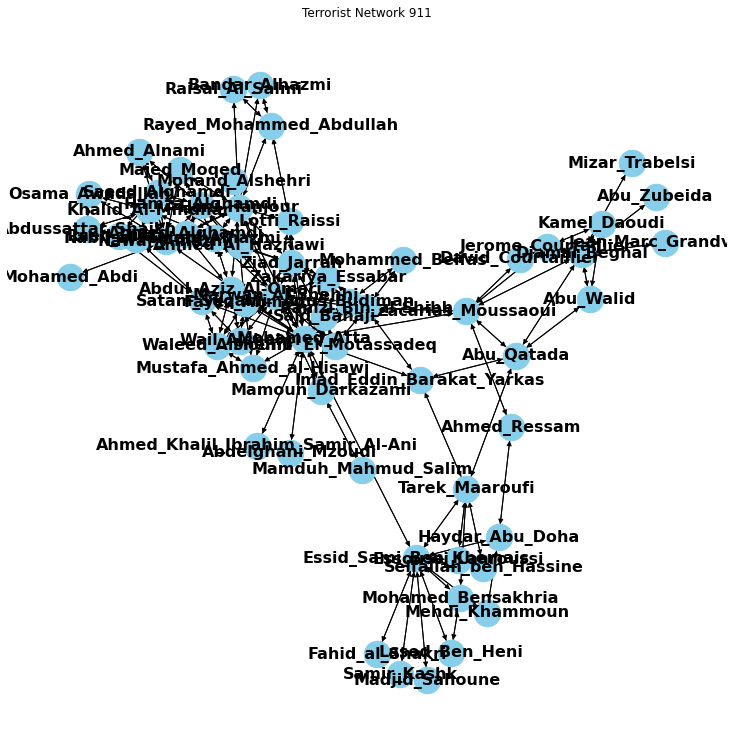

'Name: terrorist network 911\nType: DiGraph\nNumber of nodes: 62\nNumber of edges: 304\nAverage in degree:   4.9032\nAverage out degree:   4.9032'

In [4]:
# anh/chị tạo graph có hướng tên là "terrorist network 911" rồi import thông tin cạnh từ edge_list
# sau đó hiển thị tất cả thông tin của graph này ra, sử dụng hàm nx.info(...)
# cuối cùng vẽ graph này ra
# CODE HERE


# Tạo một đồ thị có hướng
G = nx.DiGraph(name="terrorist network 911")
# Thêm các cạnh vào đồ thị từ edge_list
G.add_edges_from(edge_list)

# Hiển thị thông tin của đồ thị
graph_info = nx.info(G)

# Vẽ đồ thị
plt.figure(figsize=(10, 10))
nx.draw(G, with_labels=True, node_color='skyblue', font_weight='bold', node_size=700, font_size=16)
plt.title("Terrorist Network 911")
plt.show()

graph_info


In [5]:
# điền vào chỗ trống để thực hiện thuật toán Page Rank và in ra ma trận khởi tạo
print(nx.google_matrix(G, alpha=0.85))
page_rank = nx.pagerank(G)

[[0.00241935 0.85241935 0.00241935 ... 0.00241935 0.00241935 0.00241935]
 [0.07969208 0.00241935 0.07969208 ... 0.00241935 0.00241935 0.00241935]
 [0.00241935 0.85241935 0.00241935 ... 0.00241935 0.00241935 0.00241935]
 ...
 [0.00241935 0.00241935 0.00241935 ... 0.00241935 0.28575269 0.00241935]
 [0.00241935 0.00241935 0.00241935 ... 0.28575269 0.00241935 0.00241935]
 [0.00241935 0.00241935 0.00241935 ... 0.00241935 0.00241935 0.00241935]]


In [6]:
# anh/chị chỉ cần chạy code này để in ra thứ hạng các tên khủng bố
pr_df = pd.DataFrame([{'name': k, 'value': v} for k, v in page_rank.items()])
pr_df.head()

,name,value
0,Samir_Kashk,0.006114
1,Essid_Sami_Ben_Khemais,0.047815
2,Madjid_Sahoune,0.006114
3,Fahid_al_Shakri,0.006114
4,Lased_Ben_Heni,0.009873


In [7]:
# anh/chị chỉ cần chạy code này để in ra top 10 dựa theo kết quả làm được ở trên
pr_df.sort_values('value', ascending=False).head(10)

,name,value
11,Mohamed_Atta,0.060755
1,Essid_Sami_Ben_Khemais,0.047815
31,Marwan_Al-Shehhi,0.044991
17,Djamal_Beghal,0.036374
43,Hani_Hanjour,0.035418
44,Nawaf_Alhazmi,0.032473
24,Ramzi_Bin_al-Shibh,0.027930
15,Zacarias_Moussaoui,0.026033
9,Tarek_Maaroufi,0.024306
30,Ziad_Jarrah,0.023493


In [8]:
# Trả lời câu hỏi: hằng số alpha dùng để làm gì?

**Trong thuật toán PageRank, hằng số alpha thường được sử dụng để kiểm soát tỷ lệ "nhảy" ngẫu nhiên từ một trang đến một trang khác. Thuật toán PageRank ban đầu được đề xuất bởi Larry Page và Sergey Brin của Google, và họ đã giới thiệu hằng số alpha để điều chỉnh quy tắc "nhảy" ngẫu nhiên này.
Khi giá trị của alpha gần với 1, tỷ lệ "nhảy" ngẫu nhiên giữa các trang giảm, và khi giá trị của alpha gần với 0, tỷ lệ này tăng lên. Điều này ảnh hưởng đến việc xếp hạng các trang trong kết quả PageRank.**

### Bài 5. (0.5 điểm)

Tài có $8$ người bạn sống ở $8$ địa điểm khác nhau trong thành phố IUH, có $7$ con đường đi hai chiều nối trực tiếp giữa $7$ cặp địa chỉ nào đó, thú vị là mỗi con đường có độ dài đúng $1km$. Biết rằng nếu xuất phát từ một địa điểm bất kỳ, Tài đều có thể đi được đến tất cả các địa điểm khác thông qua các con đường trên. 

Vào một ngày nắng đẹp, Tài đi Grab đến nhà của Phú, một người bạn trong số đó rồi cùng Phú đi bộ để thăm hết các bạn kia. Biết rằng cặp đôi này rất đam mê thuật toán, đặc biệt là lý thuyết khai phá đồ thị nên sẽ chọn ra cách đi tốt nhất có thể. Kết quả là hai bạn đã phải đi bộ tổng cộng $12km$ để thăm được hết nhà của các bạn còn lại, tất nhiên là chỉ được đi trên các con đường có sẵn (một nhà có thể được đi qua nhiều lần). Anh/chị hãy thử dùng networkx để vẽ bản đồ mô tả chỗ ở của $8$ bạn của Tài nhé (trong đó có chỉ rõ nhà của Phú ở đâu).

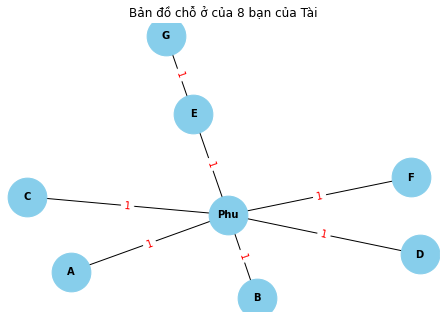

In [9]:
#CODE HERE
import networkx as nx
import matplotlib.pyplot as plt

# Tạo đồ thị
G = nx.Graph()

# Thêm các đỉnh biểu diễn cho các địa điểm
locations = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Phu']  # Phú ở địa điểm cuối cùng
G.add_nodes_from(locations)

# Thêm các cạnh biểu diễn cho các con đường
roads = [('Phu', 'A'), ('Phu', 'B'), ('Phu', 'C'), ('Phu', 'D'), ('E', 'Phu'), ('Phu', 'F'), ('G', 'E'),]
G.add_edges_from(roads)

# Vẽ đồ thị
pos = nx.spring_layout(G)  # Định vị các đỉnh
nx.draw(G, pos, with_labels=True, node_size=1500, node_color='skyblue', font_size=10, font_weight='bold')
edge_labels = {(i, j): 1 for i, j in G.edges()}  # Đánh trọng số cho các cạnh
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Bản đồ chỗ ở của 8 bạn của Tài")
plt.show()
